## 1.1 Carga del dataset final y definición de variables

En esta sección cargamos el dataset ya etiquetado (multi‑clase) y definimos la variable objetivo (`y`) y las variables predictoras (`X`). También revisamos la estructura general del conjunto de datos.


In [1]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("data/ibm_aml_multiclass_clases.csv")

df = pd.read_csv(DATA_PATH)
print("Shape del dataset:", df.shape)
print(df.head())

# Definimos el target multi-clase
TARGET_COL = "target_multi"  

# Seleccionamos un subconjunto razonable de features tabulares para empezar
FEATURE_COLS = [
    "From Bank",
    "Account",
    "To Bank",
    "Account.1",
    "Amount Received",
    "Receiving Currency",
    "Amount Paid",
    "Payment Currency",
    "Payment Format",
]

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].astype(int)

print("\nColumnas de features:", FEATURE_COLS)
print("Distribución inicial del target:")
print(y.value_counts().sort_index())


C:\Users\gipas\AppData\Local\Temp\ipykernel_22864\3864789920.py:6: DtypeWarning: Columns (0: pattern_base) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATA_PATH)


Shape del dataset: (31898238, 13)
          Timestamp  From Bank    Account  To Bank  Account.1  \
0  2022/09/01 00:17         20  800104D70       20  800104D70   
1  2022/09/01 00:02       3196  800107150     3196  800107150   
2  2022/09/01 00:17       1208  80010E430     1208  80010E430   
3  2022/09/01 00:03       1208  80010E650       20  80010E6F0   
4  2022/09/01 00:02       1208  80010E650       20  80010EA30   

   Amount Received Receiving Currency  Amount Paid Payment Currency  \
0          6794.63          US Dollar      6794.63        US Dollar   
1          7739.29          US Dollar      7739.29        US Dollar   
2          1880.23          US Dollar      1880.23        US Dollar   
3      73966883.00          US Dollar  73966883.00        US Dollar   
4      45868454.00          US Dollar  45868454.00        US Dollar   

  Payment Format  Is Laundering pattern_base  target_multi  
0   Reinvestment              0          NaN             0  
1   Reinvestment          

## 1.2 Análisis de tipos y datos faltantes

Analizamos los tipos de datos, buscamos valores perdidos y justificamos si es necesario aplicar imputación según las recomendaciones vistas en teoría (Unit 3: tipos de missingness e imputación).


In [2]:
# Tipos de datos
print("Tipos de datos en X:")
print(X.dtypes)

# Análisis de valores perdidos
missing = X.isnull().sum().sort_values(ascending=False)
print("\nNúmero de valores perdidos por columna:")
print(missing)

total_missing = missing.sum()
print(f"\nTotal de valores perdidos en X: {total_missing}")

# Si quieres ver porcentaje
missing_pct = (missing / len(X) * 100).round(6)
print("\nPorcentaje de valores perdidos por columna:")
print(missing_pct[missing_pct > 0])


Tipos de datos en X:
From Bank               int64
Account                   str
To Bank                 int64
Account.1                 str
Amount Received       float64
Receiving Currency        str
Amount Paid           float64
Payment Currency          str
Payment Format            str
dtype: object

Número de valores perdidos por columna:
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
dtype: int64

Total de valores perdidos en X: 0

Porcentaje de valores perdidos por columna:
Series([], dtype: float64)


## 1.3 Selección de variables numéricas y categóricas y estrategia de codificación

- Variables numéricas: identificadores de banco y cuentas, cantidades monetarias.
- Variables categóricas de baja cardinalidad: divisas y `Payment Format`.
- Variables categóricas de alta cardinalidad: identificadores de cuenta (`Account`, `Account.1`).

Para evitar explotar en dimensionalidad, usamos **OrdinalEncoder** en cuentas (muchas categorías)
y **OneHotEncoder** solo en las categóricas de baja cardinalidad.
Las variables numéricas se escalan con `StandardScaler` para estabilizar algunos modelos.


In [3]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Definimos columnas por tipo
num_cols = ["From Bank", "To Bank", "Amount Received", "Amount Paid"]
high_card_cat_cols = ["Account", "Account.1"]  # muchas categorías
low_card_cat_cols = ["Receiving Currency", "Payment Currency", "Payment Format"]

print("Columnas numéricas:", num_cols)
print("Categóricas alta cardinalidad:", high_card_cat_cols)
print("Categóricas baja cardinalidad:", low_card_cat_cols)

# Pipelines parciales
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

high_card_cat_transformer = Pipeline(steps=[
    ("ord_enc", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))
])

low_card_cat_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# ColumnTransformer general de preprocesado
preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("high_card_cat", high_card_cat_transformer, high_card_cat_cols),
        ("low_card_cat", low_card_cat_transformer, low_card_cat_cols),
    ]
)

print("\nPreprocesador ColumnTransformer definido.")


Columnas numéricas: ['From Bank', 'To Bank', 'Amount Received', 'Amount Paid']
Categóricas alta cardinalidad: ['Account', 'Account.1']
Categóricas baja cardinalidad: ['Receiving Currency', 'Payment Currency', 'Payment Format']

Preprocesador ColumnTransformer definido.


## 1.4 Aplicación del preprocesado a una muestra

Comprobamos que el `ColumnTransformer` se ajusta correctamente a los datos y observamos
la dimensionalidad del espacio de características transformado.


In [4]:
# Para que sea rápido, usamos una muestra pequeña al probar
X_sample = X.sample(n=50_000, random_state=42)  # ajusta n según tu RAM

X_trans = preprocess.fit_transform(X_sample)
print("Shape original X_sample:", X_sample.shape)
print("Shape transformado:", X_trans.shape)


Shape original X_sample: (50000, 9)
Shape transformado: (50000, 43)


esto se puede borrar -->


In [5]:
for col in ['Account', 'Account.1', 'Receiving Currency', 'Payment Currency', 'Payment Format']:
    print(col, "→", X[col].nunique(), "categorías")


Account → 2013627 categorías
Account.1 → 1689925 categorías
Receiving Currency → 15 categorías
Payment Currency → 15 categorías
Payment Format → 7 categorías


In [6]:
X[num_cols].describe()


,From Bank,To Bank,Amount Received,Amount Paid
count,3.189824e+07,3.189824e+07,3.189824e+07,3.189824e+07
mean,2.944094e+05,4.093198e+05,6.431116e+06,4.417551e+06
std,6.153149e+05,6.547003e+05,2.592744e+09,1.848313e+09
min,0.000000e+00,0.000000e+00,1.000000e-06,1.000000e-06
25%,2.954000e+03,2.749600e+04,2.078700e+02,2.092300e+02
50%,3.902400e+04,1.468530e+05,1.469250e+03,1.471540e+03
75%,2.158840e+05,2.598930e+05,1.183530e+04,1.175781e+04
max,3.225455e+06,3.225455e+06,8.158609e+12,8.158609e+12


---- hasta qui se puede borrar

## 2. Imbalance Analysis and Mitigation

### 2.1 Análisis del desbalance de clases

En esta sección analizamos la distribución de clases del problema multi‑clase (9 clases:
0 = normal, 1–8 = patrones AML). Esto nos permite cuantificar el grado de desbalance
antes de aplicar cualquier técnica de mitigación, tal y como se sugiere en la Unit 3
(handling imbalanced data).


Distribución de clases (recuentos):
target_multi
0    31875495
1        3986
2        2235
3        2315
4        2128
5        4289
6        3988
7        2135
8        1667
Name: count, dtype: int64

Distribución de clases (%):
target_multi
0    99.928701
1     0.012496
2     0.007007
3     0.007257
4     0.006671
5     0.013446
6     0.012502
7     0.006693
8     0.005226
Name: count, dtype: float64


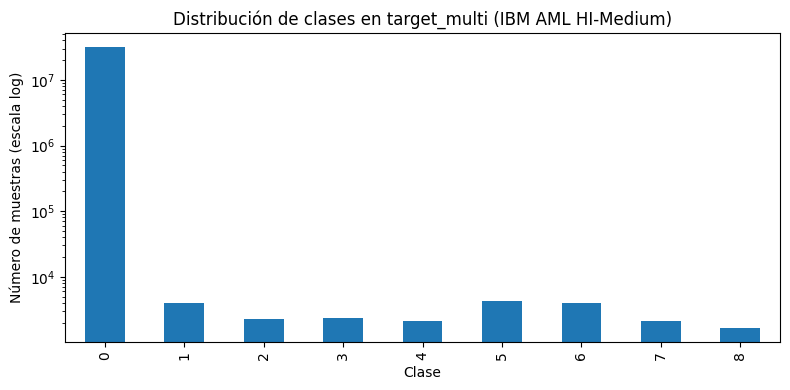

In [7]:
import matplotlib.pyplot as plt

# Distribución absoluta
class_counts = y.value_counts().sort_index()
print("Distribución de clases (recuentos):")
print(class_counts)

# Distribución porcentual
class_pct = (class_counts / len(y) * 100).round(6)
print("\nDistribución de clases (%):")
print(class_pct)

# Gráfico de barras (log-scale en y porque hay mucha diferencia)
plt.figure(figsize=(8,4))
class_counts.plot(kind="bar")
plt.yscale("log")
plt.xlabel("Clase")
plt.ylabel("Número de muestras (escala log)")
plt.title("Distribución de clases en target_multi (IBM AML HI-Medium)")
plt.tight_layout()
plt.show()


### 2.2 División estratificada en train / valid / test

Para evitar que alguna clase minoritaria desaparezca en los subconjuntos, utilizamos
`train_test_split` con la opción `stratify=y`, tal como se recomienda en la Unit 3.


In [8]:
from sklearn.model_selection import train_test_split

# 1) Train + temp (valid+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.4,      # 60% train, 40% (valid+test)
    stratify=y,
    random_state=42
)

# 2) Valid + test a partir de temp (20% / 20% del total)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,      # la mitad de 40% -> 20%
    stratify=y_temp,
    random_state=42
)

print("Tamaños:")
print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)

print("\nDistribución train:")
print(y_train.value_counts(normalize=True).sort_index().round(6))

print("\nDistribución valid:")
print(y_valid.value_counts(normalize=True).sort_index().round(6))

print("\nDistribución test:")
print(y_test.value_counts(normalize=True).sort_index().round(6))


Tamaños:
Train: (19138942, 9) Valid: (6379648, 9) Test: (6379648, 9)

Distribución train:
target_multi
0    0.999287
1    0.000125
2    0.000070
3    0.000073
4    0.000067
5    0.000134
6    0.000125
7    0.000067
8    0.000052
Name: proportion, dtype: float64

Distribución valid:
target_multi
0    0.999287
1    0.000125
2    0.000070
3    0.000073
4    0.000067
5    0.000134
6    0.000125
7    0.000067
8    0.000052
Name: proportion, dtype: float64

Distribución test:
target_multi
0    0.999287
1    0.000125
2    0.000070
3    0.000073
4    0.000067
5    0.000134
6    0.000125
7    0.000067
8    0.000052
Name: proportion, dtype: float64


### 2.3 Submuestreo inicial para poder aplicar técnicas de re-muestreo

El dataset tiene ~32M transacciones, lo que hace inviable aplicar técnicas como SMOTE
directamente. Siguiendo la idea de la Unit 3 (usar undersampling en datasets muy grandes),
creamos primero un subconjunto estratificado del conjunto de entrenamiento.


In [9]:
# Tamaño del subconjunto de entrenamiento que usaremos para demostrar las técnicas
SUBSAMPLE_SIZE = 300_000  # ajusta según tu memoria

X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train,
    train_size=SUBSAMPLE_SIZE,
    stratify=y_train,
    random_state=42
)

print("Subconjunto train para imbalance:", X_train_sub.shape)
print("Distribución en y_train_sub:")
print(y_train_sub.value_counts().sort_index())


Subconjunto train para imbalance: (300000, 9)
Distribución en y_train_sub:
target_multi
0    299786
1        37
2        21
3        22
4        20
5        40
6        38
7        20
8        16
Name: count, dtype: int64


### 2.4 Técnicas de mitigación: undersampling y oversampling

Probamos varias estrategias vistas en clase (Unit 3 y Colabs 3.1/3.2) sobre el conjunto
de entrenamiento reducido:

- Undersampling aleatorio de la clase mayoritaria.
- Oversampling con SMOTE (sintético).
- Estrategias combinadas (SMOTEENN / SMOTETomek, opcional).

Solo aplicamos re-muestreo en el conjunto de entrenamiento, nunca en validación/test.


In [10]:
from collections import Counter
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTEENN, SMOTETomek

def show_distribution(name, y_series):
    cnt = y_series.value_counts().sort_index()
    pct = (cnt / len(y_series) * 100).round(4)
    print(f"\n{name}")
    print("Counts:")
    print(cnt)
    print("Percentages:")
    print(pct)

show_distribution("Original y_train_sub", y_train_sub)

# 1) Random undersampling (reducimos la clase 0)
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_train_sub, y_train_sub)
show_distribution("RandomUnderSampler", y_rus)

# 2) SMOTE (solo numérico -> lo aplicaremos más tarde en pipeline tras preprocess)
#    Aquí, para ilustrar, hacemos SMOTE clásico asumiendo todas las features numéricas
#    (si quieres hacerlo correctamente con categóricas, usaremos SMOTE-NC o pipeline con preprocess).
smote = SMOTE(random_state=42)
X_sm, y_sm = smote.fit_resample(X_train_sub[num_cols], y_train_sub)  # ojo: solo numéricas
show_distribution("SMOTE (solo numéricas)", y_sm)

# 3) ADASYN (similar, solo numéricas, para ilustrar)
adasyn = ADASYN(random_state=42)
X_ad, y_ad = adasyn.fit_resample(X_train_sub[num_cols], y_train_sub)
show_distribution("ADASYN (solo numéricas)", y_ad)

# 4) Opcional: combinados (SMOTEENN / SMOTETomek) también sobre numéricas
smoteenn = SMOTEENN(random_state=42)
X_se, y_se = smoteenn.fit_resample(X_train_sub[num_cols], y_train_sub)
show_distribution("SMOTEENN (solo numéricas)", y_se)

smotetomek = SMOTETomek(random_state=42)
X_st, y_st = smotetomek.fit_resample(X_train_sub[num_cols], y_train_sub)
show_distribution("SMOTETomek (solo numéricas)", y_st)



Original y_train_sub
Counts:
target_multi
0    299786
1        37
2        21
3        22
4        20
5        40
6        38
7        20
8        16
Name: count, dtype: int64
Percentages:
target_multi
0    99.9287
1     0.0123
2     0.0070
3     0.0073
4     0.0067
5     0.0133
6     0.0127
7     0.0067
8     0.0053
Name: count, dtype: float64

RandomUnderSampler
Counts:
target_multi
0    16
1    16
2    16
3    16
4    16
5    16
6    16
7    16
8    16
Name: count, dtype: int64
Percentages:
target_multi
0    11.1111
1    11.1111
2    11.1111
3    11.1111
4    11.1111
5    11.1111
6    11.1111
7    11.1111
8    11.1111
Name: count, dtype: float64

SMOTE (solo numéricas)
Counts:
target_multi
0    299786
1    299786
2    299786
3    299786
4    299786
5    299786
6    299786
7    299786
8    299786
Name: count, dtype: int64
Percentages:
target_multi
0    11.1111
1    11.1111
2    11.1111
3    11.1111
4    11.1111
5    11.1111
6    11.1111
7    11.1111
8    11.1111
Name: count, dtype: 

#### 1. Análisis del desbalance
Dataset completo:

Clase 0 ≈ 99.93%

Cada clase 1–8 ≈ 0.005–0.013%
→ desbalance extremo, encaja con los ejemplos de la Unit‑3 (fraude, diagnóstico, etc.).
​

Split estratificado:

Train/Valid/Test mantienen exactamente las mismas proporciones.
→ Puedes mencionar que usas stratify=y tal y como se recomienda en la teoría para que valid/test sean representativos.

#### 2. Mitigation: interpretación de tus experimentos
Sobre el subconjunto de 300k:

Original
y_train_sub mantiene el mismo % que el dataset completo (clase 0 casi todo, resto ridículas).
→ Dejas claro por qué un modelo sin nada haría “always class 0”.

RandomUnderSampler
Todas las clases con 16 muestras (total 144).
Ventaja:

Distribución perfectamente balanceada.
Inconvenientes:

Datos ridículamente pocos, perderías casi toda la información de la clase 0.
→ En la memoria: “solo lo usamos de forma ilustrativa; para entrenar modelos no es buena idea quedarse con 16 ejemplos por clase”.

SMOTE (solo numéricas)
Todas las clases con 299 786 muestras → distribución 11.11% cada una.
→ Es el caso “súper balanceado” clásico: todas las clases igual, pero:

Has aplicado SMOTE solo sobre las columnas numéricas (num_cols), por simplicidad.

Comenta que para el modelo final preferirás usar SMOTE dentro de un Pipeline con el preprocess completo (numéricas + categóricas) o SMOTE‑NC, para que las categóricas queden bien tratadas.
​

ADASYN, SMOTEENN, SMOTETomek
ADASYN: también deja las clases casi iguales, pero generando más muestras cerca de la frontera de decisión (más agresivo en zonas “difíciles”).
​

SMOTEENN / SMOTETomek:

SMOTEENN: equilibra y “limpia” puntos conflictivos, por eso clase 0 pierde algo más de peso.

SMOTETomek: parecido, pero algo menos agresivo que SMOTEENN, todas las clases ~11%.

## 3. Model Comparison and Hyperparameter Tuning

### 3.1 Métricas y función de evaluación

Debido al fuerte desbalance, accuracy por sí sola no es informativa. Utilizaremos:
- Macro F1 (todas las clases pesan igual).
- Weighted F1 (pesa según frecuencia).
- MCC (Matthews Correlation Coefficient), recomendado en la Unit 1 para datasets
  desbalanceados.
También mostraremos la accuracy para comparar con un DummyClassifier.


In [15]:
from sklearn.metrics import accuracy_score, f1_score, matthews_corrcoef

def evaluate_model(name, clf, X_train, y_train, X_valid, y_valid):
    # Entrenamos
    clf.fit(X_train, y_train)
    
    # Predicciones en valid
    y_pred = clf.predict(X_valid)
    
    acc = accuracy_score(y_valid, y_pred)
    f1_macro = f1_score(y_valid, y_pred, average="macro")
    f1_weighted = f1_score(y_valid, y_pred, average="weighted")
    mcc = matthews_corrcoef(y_valid, y_pred)
    
    print(f"\n=== {name} ===")
    print(f"Accuracy      : {acc:.4f}")
    print(f"F1 (macro)    : {f1_macro:.4f}")
    print(f"F1 (weighted) : {f1_weighted:.4f}")
    print(f"MCC           : {mcc:.4f}")
    
    return {
        "model": name,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "mcc": mcc,
    }


### 3.2 Baselines sin técnicas de re-muestreo

Definimos dos baselines:
- Un DummyClassifier que siempre favorece la clase mayoritaria.
- Un modelo lineal sencillo (LogisticRegression multinomial) con `class_weight=None`
  y `class_weight='balanced'` para ver el efecto de las weights.


In [17]:
# =====================================================
# 3.2 Subconjunto de entrenamiento para no petar la RAM
# =====================================================

from sklearn.model_selection import train_test_split

SUBSAMPLE_SIZE = 300_000  # ajusta según la memoria que tengas

X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train, y_train,
    train_size=SUBSAMPLE_SIZE,
    stratify=y_train,
    random_state=42
)

print("Subconjunto de train para modelos:", X_train_sub.shape)
print("Distribución en y_train_sub:")
print(y_train_sub.value_counts().sort_index())


# =====================================================
# 3.3 Baselines sin técnicas de re-muestreo
# =====================================================

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

results = []

# 1) DummyClassifier (estrategia 'most_frequent')
dummy_clf = DummyClassifier(strategy="most_frequent")

dummy_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", dummy_clf),
])

results.append(
    evaluate_model(
        "Dummy most_frequent",
        dummy_pipe,
        X_train_sub, y_train_sub,   # USAMOS EL SUBCONJUNTO
        X_valid, y_valid
    )
)

# 2) Logistic Regression multinomial SIN class_weight
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

logreg_plain = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        solver="lbfgs",      # o "liblinear" si prefieres
        max_iter=200
    )),
])

results.append(
    evaluate_model(
        "LogReg (sin pesos)",
        logreg_plain,
        X_train_sub, y_train_sub,
        X_valid, y_valid
    )
)

# 3) Logistic Regression con class_weight='balanced'
logreg_bal = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=200,
        class_weight="balanced"
    )),
])

results.append(
    evaluate_model(
        "LogReg (class_weight=balanced)",
        logreg_bal,
        X_train_sub, y_train_sub,
        X_valid, y_valid
    )
)


# =====================================================
# 3.4 Tabla resumen de baselines
# =====================================================

import pandas as pd

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="f1_macro", ascending=False)
print("\nResumen de baselines (ordenados por F1-macro):")
print(results_df)

Subconjunto de train para modelos: (300000, 9)
Distribución en y_train_sub:
target_multi
0    299786
1        37
2        21
3        22
4        20
5        40
6        38
7        20
8        16
Name: count, dtype: int64


d:\Archivos Uni\4 anio\ML Avanzado\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



=== Dummy most_frequent ===
Accuracy      : 0.9993
F1 (macro)    : 0.1111
F1 (weighted) : 0.9989
MCC           : 0.0000


d:\Archivos Uni\4 anio\ML Avanzado\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



=== LogReg (sin pesos) ===
Accuracy      : 0.9993
F1 (macro)    : 0.1111
F1 (weighted) : 0.9989
MCC           : 0.0000


d:\Archivos Uni\4 anio\ML Avanzado\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)



=== LogReg (class_weight=balanced) ===
Accuracy      : 0.9993
F1 (macro)    : 0.1667
F1 (weighted) : 0.9990
MCC           : 0.1393

Resumen de baselines (ordenados por F1-macro):
                            model  accuracy  f1_macro  f1_weighted       mcc
2  LogReg (class_weight=balanced)  0.999255  0.166691     0.998974  0.139311
0             Dummy most_frequent  0.999287  0.111071     0.998931  0.000000
1              LogReg (sin pesos)  0.999287  0.111071     0.998931  0.000000


### 3.3 Modelos con re-muestreo (SMOTE) en ImbPipeline

Integramos SMOTE en un `ImbPipeline` junto con el preprocesado y comparamos sus
métricas con los baselines anteriores.
Solo aplicamos SMOTE sobre el conjunto de entrenamiento.


In [18]:
# =====================================================
# 3.3 Modelo con re-muestreo SMOTE (solo numéricas)
# =====================================================

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Para este experimento usamos solo las columnas numéricas,
# de forma que SMOTE trabaje en un espacio puramente continuo.
X_train_num = X_train_sub[num_cols].copy()
X_valid_num = X_valid[num_cols].copy()

print("Shape X_train_num:", X_train_num.shape)
print("Shape X_valid_num:", X_valid_num.shape)

# Definimos SMOTE: 'not majority' para sobremuestrear solo las minoritarias
smote = SMOTE(
    sampling_strategy="not majority",
    random_state=42
)

logreg_smote = ImbPipeline(steps=[
    ("scaler", StandardScaler()),      # estandarizamos numéricas
    ("smote", smote),                 # re-muestreo en train
    ("model", LogisticRegression(
        solver="lbfgs",
        max_iter=200,
        class_weight=None             # aquí dejamos que SMOTE haga el trabajo
    )),
])

results.append(
    evaluate_model(
        "LogReg + SMOTE (solo numéricas)",
        logreg_smote,
        X_train_num, y_train_sub,     # train submuestreado + SMOTE
        X_valid_num, y_valid          # valid sin tocar
    )
)

# Actualizamos tabla de resultados
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="f1_macro", ascending=False)
print("\nResumen de modelos (incluyendo SMOTE):")
print(results_df)


Shape X_train_num: (300000, 4)
Shape X_valid_num: (6379648, 4)

=== LogReg + SMOTE (solo numéricas) ===
Accuracy      : 0.3658
F1 (macro)    : 0.0597
F1 (weighted) : 0.5355
MCC           : 0.0060

Resumen de modelos (incluyendo SMOTE):
                             model  accuracy  f1_macro  f1_weighted       mcc
2   LogReg (class_weight=balanced)  0.999255  0.166691     0.998974  0.139311
0              Dummy most_frequent  0.999287  0.111071     0.998931  0.000000
1               LogReg (sin pesos)  0.999287  0.111071     0.998931  0.000000
3  LogReg + SMOTE (solo numéricas)  0.365849  0.059732     0.535482  0.005987


“Debido al tamaño del dataset (≈32M transacciones), tanto el entrenamiento como la búsqueda de hiperparámetros se realizan sobre subconjuntos estratificados de entrenamiento y validación (300k y 500k ejemplos, respectivamente), manteniendo la distribución de clases. Esto sigue las recomendaciones vistas en clase para tuning en datasets masivos, reduciendo significativamente el coste computacional sin perder representatividad.”

In [21]:
# =====================================================
# 3.4 Optuna + Ensembles (4 modelos) con validación reducida
# =====================================================

import optuna
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier,
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

# Subconjunto estratificado de validación para Optuna
VALID_OPT_SIZE = 200_000  # ajusta según tu RAM

X_valid_opt, _, y_valid_opt, _ = train_test_split(
    X_valid, y_valid,
    train_size=VALID_OPT_SIZE,
    stratify=y_valid,
    random_state=42
)

print("Shape X_valid_opt:", X_valid_opt.shape)
print("Distribución en y_valid_opt:")
print(y_valid_opt.value_counts().sort_index())


# ---------- 3.4.1 Random Forest ----------

def objective_rf(trial):
    n_estimators = trial.suggest_int("n_estimators", 80, 200)
    max_depth = trial.suggest_int("max_depth", 5, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        max_features=max_features,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        n_jobs=1,                    # menos paralelismo -> menos RAM
        class_weight="balanced_subsample",
        random_state=42,
    )

    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model),
    ])

    pipe.fit(X_train_sub, y_train_sub)
    y_pred = pipe.predict(X_valid_opt)
    f1_macro = f1_score(y_valid_opt, y_pred, average="macro")
    return f1_macro


study_rf = optuna.create_study(direction="maximize")
study_rf.optimize(objective_rf, n_trials=10)

print("\n[RandomForest] Mejor F1-macro (valid_opt):", study_rf.best_value)
print("[RandomForest] Mejores params:", study_rf.best_params)

best_rf = RandomForestClassifier(
    **{
        **study_rf.best_params,
        "n_jobs": 1,
        "class_weight": "balanced_subsample",
        "random_state": 42,
    }
)

rf_best_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", best_rf),
])

results.append(
    evaluate_model(
        "RandomForest (Optuna)",
        rf_best_pipe,
        X_train_sub, y_train_sub,
        X_valid, y_valid           # ahora sí, evaluación final en todo valid
    )
)


# ---------- 3.4.2 ExtraTrees ----------

def objective_et(trial):
    n_estimators = trial.suggest_int("n_estimators", 80, 200)
    max_depth = trial.suggest_int("max_depth", 5, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2"])
    min_samples_split = trial.suggest_int("min_samples_split", 2, 10)
    min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 10)

    model = ExtraTreesClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        max_features=max_features,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        n_jobs=1,
        class_weight="balanced_subsample",
        random_state=42,
    )

    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model),
    ])

    pipe.fit(X_train_sub, y_train_sub)
    y_pred = pipe.predict(X_valid_opt)
    return f1_score(y_valid_opt, y_pred, average="macro")


study_et = optuna.create_study(direction="maximize")
study_et.optimize(objective_et, n_trials=10)

print("\n[ExtraTrees] Mejor F1-macro (valid_opt):", study_et.best_value)
print("[ExtraTrees] Mejores params:", study_et.best_params)

best_et = ExtraTreesClassifier(
    **{
        **study_et.best_params,
        "n_jobs": 1,
        "class_weight": "balanced_subsample",
        "random_state": 42,
    }
)

et_best_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", best_et),
])

results.append(
    evaluate_model(
        "ExtraTrees (Optuna)",
        et_best_pipe,
        X_train_sub, y_train_sub,
        X_valid, y_valid
    )
)


# ---------- 3.4.3 Gradient Boosting ----------

def objective_gb(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 150)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.2, log=True)
    max_depth = trial.suggest_int("max_depth", 2, 5)
    subsample = trial.suggest_float("subsample", 0.6, 1.0)

    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        random_state=42,
    )

    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model),
    ])

    pipe.fit(X_train_sub, y_train_sub)
    y_pred = pipe.predict(X_valid_opt)
    return f1_score(y_valid_opt, y_pred, average="macro")


study_gb = optuna.create_study(direction="maximize")
study_gb.optimize(objective_gb, n_trials=10)

print("\n[GradBoost] Mejor F1-macro (valid_opt):", study_gb.best_value)
print("[GradBoost] Mejores params:", study_gb.best_params)

best_gb = GradientBoostingClassifier(
    **{
        **study_gb.best_params,
        "random_state": 42,
    }
)

gb_best_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", best_gb),
])

results.append(
    evaluate_model(
        "GradientBoosting (Optuna)",
        gb_best_pipe,
        X_train_sub, y_train_sub,
        X_valid, y_valid
    )
)


# ---------- 3.4.4 AdaBoost ----------

def objective_ab(trial):
    n_estimators = trial.suggest_int("n_estimators", 50, 150)
    learning_rate = trial.suggest_float("learning_rate", 0.01, 1.0, log=True)

    model = AdaBoostClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=42,
    )

    pipe = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", model),
    ])

    pipe.fit(X_train_sub, y_train_sub)
    y_pred = pipe.predict(X_valid_opt)
    return f1_score(y_valid_opt, y_pred, average="macro")


study_ab = optuna.create_study(direction="maximize")
study_ab.optimize(objective_ab, n_trials=10)

print("\n[AdaBoost] Mejor F1-macro (valid_opt):", study_ab.best_value)
print("[AdaBoost] Mejores params:", study_ab.best_params)

best_ab = AdaBoostClassifier(
    **{
        **study_ab.best_params,
        "random_state": 42,
    }
)

ab_best_pipe = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", best_ab),
])

results.append(
    evaluate_model(
        "AdaBoost (Optuna)",
        ab_best_pipe,
        X_train_sub, y_train_sub,
        X_valid, y_valid
    )
)


# ---------- 3.4.5 Resumen final ----------

results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="f1_macro", ascending=False)
print("\nResumen de todos los modelos (baselines + SMOTE + ensembles):")
print(results_df)


[I 2026-03-11 12:30:09,441] A new study created in memory with name: no-name-0397aa2a-1a56-4829-9223-e8207aaacf08


Shape X_valid_opt: (200000, 9)
Distribución en y_valid_opt:
target_multi
0    199857
1        25
2        14
3        15
4        13
5        27
6        25
7        13
8        11
Name: count, dtype: int64


d:\Archivos Uni\4 anio\ML Avanzado\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
[I 2026-03-11 12:30:30,057] Trial 0 finished with value: 0.003832550491282371 and parameters: {'n_estimators': 173, 'max_depth': 18, 'max_features': 'log2', 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 0 with value: 0.003832550491282371.
d:\Archivos Uni\4 anio\ML Avanzado\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
[I 2026-03-11 12:30:48,142] Trial 1 finished with value: 0.0038293275265142285 and parameters: {'n_estimators': 155, 'max_depth': 16, 'max_features': 'log2', 'min_samples_


[RandomForest] Mejor F1-macro (valid_opt): 0.05962333936238032
[RandomForest] Mejores params: {'n_estimators': 151, 'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 4, 'min_samples_leaf': 7}


d:\Archivos Uni\4 anio\ML Avanzado\MoneyLaunderingClassifier\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


MemoryError: Unable to allocate 195. MiB for an array with shape (25518592,) and data type float64